# Задача 1

In [ ]:
format ELF64

public _start

section ".data" writeable
    buffer db 16

section ".text" executable
_start:
    pop rax

    cmp rax, 2
    jl exit

    pop rdi
    pop rdi
    xor rax, rax
    mov al, byte [rdi]
    call print_int
    jmp exit

exit:
    mov rax,60
    xor rdi, rdi
    syscall

print_int:
    push rsi
    push rdi
    push rdx
    push rbx
    mov rsi, 0
    mov rdi, 10

    @@:
        xor rdx, rdx
        div rdi
        add rdx, '0'
        mov [buffer + rsi], dl
        inc rsi

        cmp rax, 0
        jg @b

    mov [buffer + rsi], 10

    mov rdi, buffer
    add rdi, rsi
    dec rdi
    mov rsi, buffer

    @@:
    cmp rsi, rdi
    jge @f

    mov al, [rsi]
    mov bl, [rdi]
    mov [rsi], bl
    mov [rdi], al

    inc rsi
    dec rdi
    jmp @b
    @@:

    mov rax, 1
    mov rdi, 1
    mov rsi, buffer
    syscall

    pop rbx
    pop rdx
    pop rdi
    pop rsi
    ret

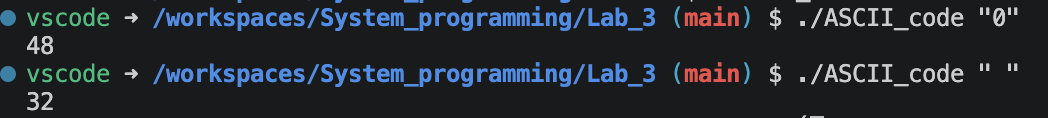

# Задача 2

дано:
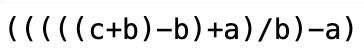

In [ ]:
format ELF64

public _start

section ".data" writeable
    buffer db 16

section ".text" executable
_start:
    pop rax
    cmp rax, 4
    jl exit

    pop R8
    pop rax
    call ATOI
    mov R8, rcx
    pop rax
    call ATOI
    mov R9, rcx
    pop rax
    call ATOI
    mov R10, rcx

    add R10,R8

    xor rdx, rdx
    mov rax, R10
    div R9
    sub rax, R8
    call print_int
    jmp exit



exit:
    mov rax,60
    xor rdi, rdi
    syscall

;input: rax - pointer to the string
;output: rcx - integer
ATOI:
    push rsi ; pointer to end of string
    push rdx ; pointer to the string
    push rbx
    push R9
    push R8 ; хранит в себе не полный результат приобразования

    mov rsi, rax ; rsi должен указывать на конец строки
    mov rbx, rax
    xor R8, R8
    mov R9, 10 ; основание СС

    mov rax, 1 ; здесь хранятся степени 10

    @@: ; двигаем rsi до тех пор пока не встретим символ конца строки
        cmp byte [rsi], 0
        je @f
        inc rsi
        jmp @b
    @@:

    dec rsi
    @@:
    xor rcx, rcx
        mov cl, [rsi] ; Получаем ASCII код цифры
        sub rcx, '0' ; из ASCII получаем само значение цифры
        push rax
        mul rcx ; умножаем степень 10 на цифру

        add R8, rax; складываем результат умножения с предварительным результатом
        pop rax
        mul R9 ; увеличиваем степень 10

        cmp rsi,rbx ; проверяем не закончилось ли число
        je @f
        dec rsi
        jmp @b
    @@:

    mov rcx,R8

    pop R8
    pop R9
    pop rbx
    pop rdx
    pop rsi
    ret

;input: rax - number for print
print_int:
    push rsi
    push rdi
    push rdx
    push rbx
    mov rsi, 0
    mov rdi, 10

    @@:
        xor rdx, rdx
        div rdi
        add rdx, '0'
        mov [buffer + rsi], dl
        inc rsi

        cmp rax, 0
        jg @b

    mov [buffer + rsi], 10

    mov rdi, buffer
    add rdi, rsi
    dec rdi
    mov rsi, buffer

    @@:
    cmp rsi, rdi
    jge @f

    mov al, [rsi]
    mov bl, [rdi]
    mov [rsi], bl
    mov [rdi], al

    inc rsi
    dec rdi
    jmp @b
    @@:

    mov rax, 1
    mov rdi, 1
    mov rsi, buffer
    syscall

    pop rbx
    pop rdx
    pop rdi
    pop rsi
    ret

# Задача 3

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main(int argc, char *argv[]) {
    unsigned int a, b, c;
    unsigned int result;

    if (argc != 4) {
        return 1; // Выходим с ошибкой
    }

    a = atof(argv[1]);
    b = atof(argv[2]);
    c = atof(argv[3]);

    if (b == 0) {
        return 1;
    }

    result = (((((c + b) - b) + a) / b) - a);

    printf("%u\n", result);

    return 0;
}

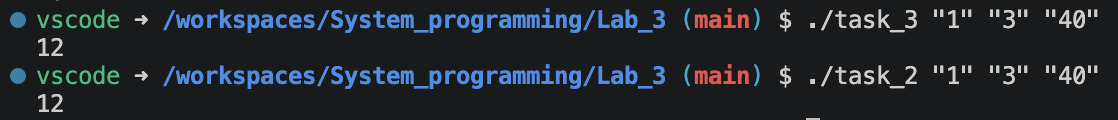

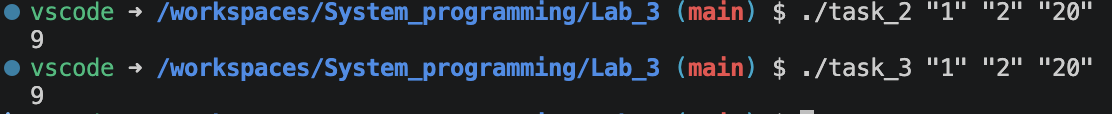